In [8]:
from __future__ import print_function
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.18.1
#   kernelspec:
#     display_name: Python 2
#     language: python
#     name: python2
# ---

import warnings
warnings.filterwarnings('ignore')

<h1>MIMIC Treatment Disparities, Stratified by Race</h1>

In [9]:
from __future__ import absolute_import
from builtins import str
from builtins import range
from past.utils import old_div
import psycopg2
import pandas as pd
import time
from collections import defaultdict
import tqdm
import pylab as pl
import numpy as np
from scipy.stats import mannwhitneyu
from six.moves import range

In [10]:
# create a database connection
sqluser = 'wboag'
dbname = 'mimiciv'

# Connect to the database
# con = psycopg2.connect(dbname=dbname, user=sqluser, host="/var/run/postgresql")
con = psycopg2.connect(dbname=dbname, user=sqluser, host="host.docker.internal", port="5432")

<h1>Query for Demographics and Cohort</h1>

In [11]:
# Preprocessing / Normalization

def normalize_race(race):
    if 'HISPANIC' in race:
        return 'Hispanic'
    if 'SOUTH AMERICAN' in race:
        return 'Hispanic'
    if 'AMERICAN INDIAN' in race:
        return 'Native American'
    if 'ASIAN' in race:
        return 'Asian'
    if 'BLACK' in race:
        return 'Black'
    if 'UNKNOWN/NOT SPECIFIED' in race:
        return 'Not Specified'
    if 'WHITE' in race:
        return 'White'
    #print race
    return 'Other'

def normalize_insurance(ins):
    if ins in ['Government', 'Medicaid', 'Medicare']:
        return 'Public'
    elif ins == 'Private':
        return 'Private'
    else:
        return 'Self-Pay'

def normalize_discharge(disch):
    if disch.startswith('HOSPICE'):
        return 'Hospice'
    if disch == 'DEAD/EXPIRED':
        return 'Deceased'
    if disch.startswith('SNF'):
        return 'Skilled Nursing Facility'
    return 'other'

def normalize_codestatus(code):
    if code is not None:
        if ('DNR' in code) or ('DNI' in code) or ('Comfort' in code) or ('Do Not' in code):
            label = 'DNR/CMO'
        elif (code == 'Full Code') or (code == 'Full code'):
            label = 'Full Code'
        else:
            label = code
    else:
        label = 'Not specified'
    return label

    
def normalize_age(age):
    return min(age, 90)

In [12]:
# static demographic info
# [repro] note: updated age to admission_age
print(time.strftime("%Y-%m-%d %H:%M:%s"))
demographics_query = """
SELECT DISTINCT
    subject_id,
    hadm_id,
    gender,
    CASE
      WHEN admission_age > 89 THEN 90
      ELSE ROUND(admission_age)
    END AS age,
    race AS ethnicity
FROM mimiciv_derived.icustay_detail
WHERE first_icu_stay = TRUE;
"""
demographics = pd.read_sql_query(demographics_query, con)
print(time.strftime("%Y-%m-%d %H:%M:%s"))

2025-12-04 02:54:1764816877
2025-12-04 02:54:1764816877


In [13]:
# admissions info
print(time.strftime("%Y-%m-%d %H:%M:%s"))
discharge_query = """
SELECT DISTINCT subject_id,hadm_id,race AS ethnicity,insurance,discharge_location,admittime,dischtime
FROM mimiciv_hosp.admissions
WHERE discharge_location IS NOT NULL;
"""
discharge = pd.read_sql_query(discharge_query, con)

discharge['discharge_location'] = discharge['discharge_location'].apply(normalize_discharge)
print(time.strftime("%Y-%m-%d %H:%M:%s"))

2025-12-04 02:54:1764816877
2025-12-04 02:54:1764816878


In [14]:
# Code Status
print(time.strftime("%Y-%m-%d %H:%M:%s"))
code_query = """
SELECT DISTINCT 
  hadm_id,
  label,
  value AS code_status 
FROM mimiciv_icu.chartevents c 
JOIN mimiciv_icu.d_items i 
ON i.itemid = c.itemid 
WHERE label = 'Code Status'
"""
code_status = pd.read_sql_query(code_query, con)

code_status['code_status'] = code_status['code_status'].apply(normalize_codestatus)
print(time.strftime("%Y-%m-%d %H:%M:%s"))

2025-12-04 02:54:1764816878
2025-12-04 02:54:1764816885


In [15]:
print(time.strftime("%Y-%m-%d %H:%M:%s"))
mort_outcome = pd.read_sql_query('select subject_id,dod from mimiciv_hosp.patients', con)
mortality = pd.read_sql_query('select subject_id,dod from mimiciv_hosp.patients where dod is not null;', con)
print(time.strftime("%Y-%m-%d %H:%M:%s"))

mortality.head()

2025-12-04 02:54:1764816885
2025-12-04 02:54:1764816885


,subject_id,dod
0,10000032,2180-09-09
1,10000084,2161-02-13
2,10000690,2152-01-30
3,10000935,2187-11-12
4,10000947,2121-08-23


In [16]:
# EOL Cohort

print(time.strftime("%Y-%m-%d %H:%M:%s"))

# patients who died or went to hospice
#eol_locations = {'Hospice', 'Deceased'}
eol_locations = {'Hospice', 'Deceased', 'Skilled Nursing Facility'}
disch = discharge.loc[discharge['discharge_location'].isin(eol_locations)]

ids =  set(disch.hadm_id.values)
eol_cohort_initial = discharge.loc[discharge.hadm_id.isin(ids)]

inds_at_least_6hrs = eol_cohort_initial['dischtime'] - eol_cohort_initial['admittime'] > pd.Timedelta(days=1)
eol_cohort_initial = eol_cohort_initial.loc[inds_at_least_6hrs]


# add demographics info
eol_cohort = pd.merge(eol_cohort_initial, demographics, on=['hadm_id','ethnicity'])
eol_cohort = eol_cohort.rename(columns={'ethnicity':'race'})

# normalize columns of data
eol_cohort['race'              ] = eol_cohort['race'              ].apply(normalize_race)
eol_cohort['insurance'         ] = eol_cohort['insurance'         ].apply(normalize_insurance)
eol_cohort['discharge_location'] = eol_cohort['discharge_location'].apply(normalize_discharge)
eol_cohort['age'               ] = eol_cohort['age'               ].apply(normalize_age)

los = eol_cohort['dischtime'] - eol_cohort['admittime']
eol_cohort['los'] = los.apply(lambda t:t.seconds/3600.)
    

# make sure each hadm_id has only died once
assert len(eol_cohort) == len(set(eol_cohort['hadm_id'].values))
print('eol subjects:', len(set(eol_cohort['hadm_id'].values)))

print(time.strftime("%Y-%m-%d %H:%M:%s"))

#eol_cohort.head()

2025-12-04 02:54:1764816885
eol subjects: 2081
2025-12-04 02:54:1764816885


In [17]:
# Stratify by race
race_eol = {}
for race in ['White', 'Black']:
    loc = eol_cohort['race'] == race
    race_eol[race] = eol_cohort.loc[loc]
    
race_eol['Black'].head()

,subject_id_x,hadm_id,race,insurance,discharge_location,admittime,dischtime,subject_id_y,gender,age,los
2,11018127,21344047,Black,Public,other,2186-06-30 03:14:00,2186-07-08 17:00:00,11018127,F,83.0,13.766667
9,11014390,20547049,Black,Public,other,2116-05-17 15:24:00,2116-05-20 14:25:00,11014390,M,70.0,23.016667
25,10284680,27529139,Black,Public,other,2190-02-20 12:24:00,2190-03-01 22:38:00,10284680,F,73.0,10.233333
40,10908257,23058192,Black,Public,other,2185-09-26 14:45:00,2185-10-02 18:36:00,10908257,F,82.0,3.850000
46,10532466,26825602,Black,Public,other,2181-03-11 17:47:00,2181-03-15 11:50:00,10532466,F,87.0,18.050000


<h1>Load Treatments from MIMIC</h1>

In [18]:
# Useful processing tools for treatment duration data

def find(groups, it):
    for i,group in enumerate(groups):
        if it in group:
            return i

        
def transitive_closure(items, merge):
    groups = [ [it] for it in items ]
    for a,b in merge:
        # make sure a and b are in the same group
        group_a = find(groups, a)
        group_b = find(groups, b)
        if group_a < group_b:
            group_ab = groups[group_a] + groups[group_b]
            del groups[group_b]
            del groups[group_a]
            groups.append(group_ab)
        elif group_a > group_b:
            group_ab = groups[group_a] + groups[group_b]
            del groups[group_a]
            del groups[group_b]
            groups.append(group_ab)
        else:
            # already same group
            pass
    return groups


def treatment_quantity(duration_aggregate, treatment_df):
    spans = defaultdict(list)
    for hadm_id,rows in tqdm.tqdm(treatment_df.groupby('hadm_id')):
        rows =  rows.sort_values('starttime')

        if duration_aggregate == 'max-min':
            span = rows.iloc[-1].endtime - rows.iloc[0].starttime
            assert span > pd.Timedelta(days=0)
            spans[hadm_id].append(span)   
        elif duration_aggregate == 'sum_spans':
            merge = []
            for i in range(len(rows)-1):
                if rows.iloc[i+1].starttime - rows.iloc[i].endtime <= pd.Timedelta(hours=10):
                    merge.append( (i,i+1) )

            for group in transitive_closure(list(range(len(rows))), merge):
                lo = min(group)
                hi = max(group)
                span = rows.iloc[hi].endtime - rows.iloc[lo].starttime
                assert span >= pd.Timedelta(days=0)
                spans[hadm_id].append(span)
        else:
            raise Exception('dunno!')

    quantity = { hadm_id:sum([ts.total_seconds()/60. for ts in timestamps]) for hadm_id,timestamps in list(spans.items()) }
    #quantity = { hadm_id:timestamps[0].total_seconds()/60. for hadm_id,timestamps in spans.items() }
    #quantity = { hadm_id:timestamps[-1].total_seconds()/60. for hadm_id,timestamps in spans.items() }
    
    return quantity

In [19]:
# Mechanical Ventilation
query ="""
SELECT
    i.hadm_id,
    v.starttime,
    v.endtime
FROM mimiciv_derived.icustay_detail AS i
INNER JOIN mimiciv_derived.ventilation AS v
    ON i.stay_id = v.stay_id
WHERE v.starttime BETWEEN i.icu_intime AND i.icu_outtime
  AND v.endtime   BETWEEN i.icu_intime AND i.icu_outtime;
"""
vent_df = pd.read_sql_query(query, con)

vent_quantity = treatment_quantity('sum_spans', vent_df)
#print dict(vent_quantity.items()[:5])

100%|██████████| 61259/61259 [00:34<00:00, 1776.92it/s]


In [20]:
# Vasopressors
# [repro] note: updated `vasopressordurations` to `vasopressor_durations`
query = """
select i.hadm_id, v.starttime, v.endtime
FROM mimiciv_derived.icustay_detail i
INNER JOIN mimiciv_derived.vasopressin v ON i.stay_id = v.stay_id
where v.starttime between icu_intime and icu_outtime
and   v.endtime   between icu_intime and icu_outtime
"""
vaso_df = pd.read_sql_query(query,con)

vaso_quantity = treatment_quantity('sum_spans', vaso_df)
#print dict(vaso_quantity.items()[:5])

100%|██████████| 5449/5449 [00:06<00:00, 838.92it/s]


<h1>Visualize CDF of Treatments</h1>

In [21]:
%matplotlib inline

import pylab as pl
import numpy as np
from scipy.stats import mannwhitneyu

white_eol = eol_cohort.loc[eol_cohort['race'].isin(['White'])]
black_eol = eol_cohort.loc[eol_cohort['race'].isin(['Black'])]

# Put each treatment into the dictionary
T = {}

white_eol_vaso = {hadm_id:vaso_quantity[hadm_id] for hadm_id in race_eol['White']['hadm_id'].values if hadm_id in vaso_quantity}
black_eol_vaso = {hadm_id:vaso_quantity[hadm_id] for hadm_id in race_eol['Black']['hadm_id'].values if hadm_id in vaso_quantity}
T['vaso'] =  {'Black':black_eol_vaso, 'White':white_eol_vaso}

white_eol_vent = {hadm_id:vent_quantity[hadm_id] for hadm_id in race_eol['White']['hadm_id'].values if hadm_id in vent_quantity}
black_eol_vent = {hadm_id:vent_quantity[hadm_id] for hadm_id in race_eol['Black']['hadm_id'].values if hadm_id in vent_quantity}
T['vent'] =  {'Black':black_eol_vent, 'White':white_eol_vent}

vaso
	white: 83 2730.0
	black: 11 1750.0
	p-value: 0.09385544334598983


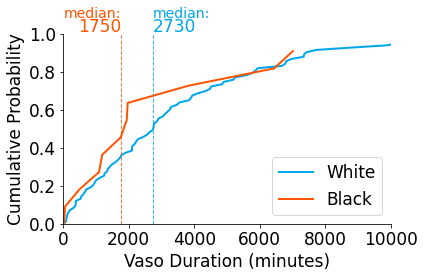

vent
	white: 1109 2685.0
	black: 146 2640.0
	p-value: 0.3919923270918631


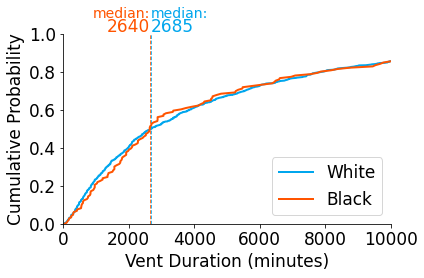

In [22]:

def list_median(vals):
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#00A6ED', '#FF5400']
for treatment in list(T.keys()):
    i = 0
    
    fig = pl.figure(treatment)

    white_median = list_median(list(T[treatment]['White'].values()))
    black_median = list_median(list(T[treatment]['Black'].values()))
    larger_median = min(white_median, black_median)
        
    for demographic in ['White', 'Black']:
        vals = list(T[treatment][demographic].values())
        pl.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
        pl.xlim((0,10000))
        pl.ylim((0,1.0))

        median = np.sort(vals)[int(old_div(len(vals),2))]
        pl.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
        if median == larger_median:
            p = 10
            h = 'right'
        else:
            p = -10
            h = 'left'
        pl.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
        pl.text(x=median+p, y=1.01 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[i])

        i += 1

    ax = pl.subplot(111)    
    ax.spines["top"].set_visible(False)    
    ax.spines["right"].set_visible(False)    
    pl.yticks(fontsize=17)    
    pl.xticks(fontsize=17) 

    pl.legend(loc=4, fontsize=17)
    pl.ylabel("Cumulative Probability", fontsize=17)
    pl.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

    pl.tight_layout()
    pl.savefig('../images/chapter3/race_mimic_%s.png' % treatment)

    p1 = list(T[treatment]['White'].values())
    p2 = list(T[treatment]['Black'].values())
    w = mannwhitneyu(p1, p2)
    print(treatment)
    print('\twhite:', len(p1), white_median)
    print('\tblack:', len(p2), black_median)
    print('\tp-value:', w.pvalue)
    
    pl.show()

<h1>Race-based Treatment Disparities, Stratified by Severity</h1>

In [23]:
# load oasis severity scores
oasis_query = 'select hadm_id,max(oasis) as oasis from mimiciv_derived.oasis group by hadm_id'
oasis_df = pd.read_sql_query(oasis_query, con)
severities = dict(oasis_df[['hadm_id','oasis']].values)
print(len(severities))

85242


In [24]:
treatment_severity_populations = {treatment:[] for treatment in list(T.keys())}
for treatment,race_cohorts in tqdm.tqdm(list(T.items())):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            severity = severities[hadm_id]
            treatment_severity_populations[treatment].append(severity)

treatment_severity_thresholds = {}
for treatment,scores in list(treatment_severity_populations.items()):
    vals = sorted(scores)
    n = len(vals)
    print(treatment, vals[old_div(n,3)], vals[old_div(2*n,3)], '||', len(vals[:old_div(n,3)]), len(vals[old_div(n,3):old_div(2*n,3)]), len(vals[old_div(2*n,3):]))
    treatment_severity_thresholds[treatment] = vals[old_div(n,3)], vals[old_div(2*n,3)]

100%|██████████| 2/2 [00:00<00:00, 3577.23it/s]

vaso 37 46 || 31 31 32
vent 31 38 || 418 418 419


In [25]:
# partition by treatment
T_risk = defaultdict(lambda:defaultdict(lambda:defaultdict(list)))
for treatment,race_cohorts in tqdm.tqdm(list(T.items())):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            # acuity bin
            severity = severities[hadm_id]
            if severities[hadm_id] <= treatment_severity_thresholds[treatment][0]:
                acuity = 'low'
            elif severities[hadm_id] <= treatment_severity_thresholds[treatment][1]:
                acuity = 'medium'
            else:
                acuity = 'high'

            T_risk[treatment][acuity][race].append(amount)

for treatment,cohorts in list(T_risk.items()):
    print(treatment)
    for severity in ['low', 'medium', 'high']:
        print('\t', severity)
        cohort = cohorts[severity]
        for race,ids in list(cohort.items()):
            print('\t\t', race, len(ids))

100%|██████████| 2/2 [00:00<00:00, 2174.90it/s]

vaso
	 low
		 Black 5
		 White 30
	 medium
		 Black 5
		 White 28
	 high
		 Black 1
		 White 25
vent
	 low
		 Black 48
		 White 376
	 medium
		 Black 45
		 White 380
	 high
		 Black 53
		 White 353


vaso
	 vaso low
		white: 30 2100.0
		black: 5 1937.0
		p-value: 0.3103089732188449


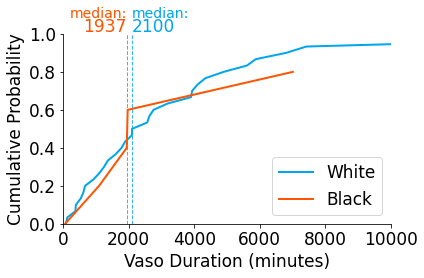

	 vaso medium
		white: 28 3283.0
		black: 5 1750.0
		p-value: 0.233294597641932


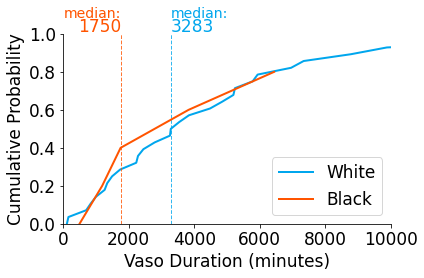

	 vaso high
		white: 25 2758.0
		black: 1 22.0
		p-value: 0.0712333774139861


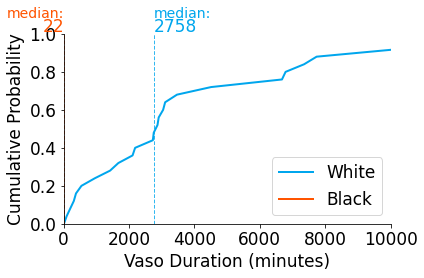

vent
	 vent low
		white: 376 2091.0
		black: 48 2280.0
		p-value: 0.20259089957707033


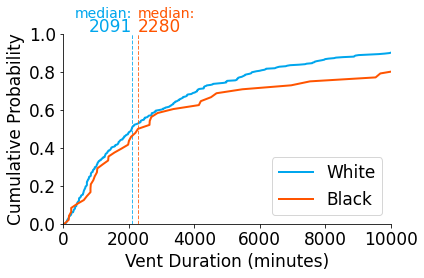

	 vent medium
		white: 380 2520.0
		black: 45 2459.0
		p-value: 0.3291867443163159


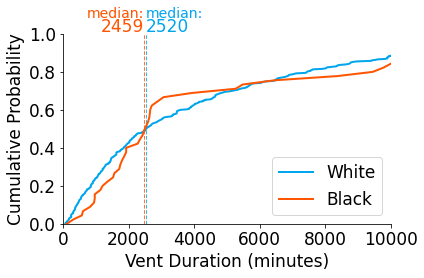

	 vent high
		white: 353 3840.0
		black: 53 3343.0
		p-value: 0.11974207801709635


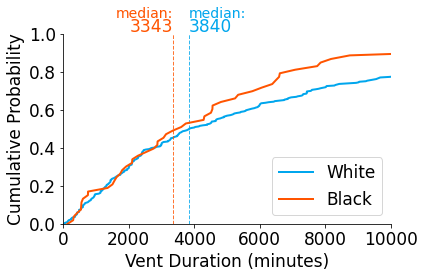

In [26]:
for treatment in list(T_risk.keys()):
    print(treatment)

    for severity in ['low','medium','high']:
        fig = pl.figure('-'.join([treatment,severity]))
        print('\t', treatment, severity)

        white_median = list_median(T_risk[treatment][severity]['White'])
        black_median = list_median(T_risk[treatment][severity]['Black'])
        larger_median = min(white_median, black_median)
        
        for i,demographic in enumerate(['White', 'Black']):
            vals = list(T_risk[treatment][severity][demographic])
            #print(len(vals))
            #print (np.sort(vals)[int(len(vals)/2)])
            pl.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
            pl.xlim((0,10000))
            pl.ylim((0,1.0))

            median = np.sort(vals)[int(old_div(len(vals),2))]
            pl.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
            if median == larger_median:
                p = 10
                h = 'right'
            else:
                p = -10
                h = 'left'
            #h = 'center'
            pl.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
            pl.text(x=median+p, y=1.01 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[i])

        ax = pl.subplot(111)    
        ax.spines["top"].set_visible(False)    
        #ax.spines["bottom"].set_visible(False)    
        ax.spines["right"].set_visible(False)    
        #ax.spines["left"].set_visible(False)    
        pl.yticks(fontsize=17)    
        pl.xticks(fontsize=17) 

        pl.legend(loc=4, fontsize=17)
        pl.ylabel("Cumulative Probability", fontsize=17)
        pl.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

        pl.tight_layout()
        pl.savefig('../images/chapter3/race_mimic_%s_%s.png' % (treatment,severity))

        p1 = list(T_risk[treatment][severity]['White'])
        p2 = list(T_risk[treatment][severity]['Black'])
        w = mannwhitneyu(p1, p2)
        print('\t\twhite:', len(p1), white_median)
        print('\t\tblack:', len(p2), black_median)
        print('\t\tp-value:', w.pvalue)
        pl.show()
    #exit()